# Bayesian Network (BN) Analysis of a Smart Water Treatment Plant Cyber-Safety System


##Scenario Overview

Modern water treatment plants rely heavily on:

- Sensors for monitoring water quality  
- Automated chemical dosing systems  
- Networked control systems  
- Human operator supervision  

However, these systems are vulnerable to both **cyber attacks** and **technical faults**.

Key risk factors include:

- Intrusion attempts targeting control systems  
- Sensor tampering or data manipulation  
- Chemical dosing errors  
- Failure of water quality monitoring  
- Delayed operator response  

These failures can propagate through the system and lead to a critical outcome:

 **Unsafe water release into the supply system**



#  Install Libraries and Import Packages

This block installs and imports the libraries needed for Bayesian Network modelling and visualization.

In [1]:
# Install required libraries
!pip install pgmpy networkx matplotlib pandas

# Import pandas for tables
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import networkx for graph visualization
import networkx as nx

# Import Bayesian Network model
from pgmpy.models import DiscreteBayesianNetwork

# Import CPD class
from pgmpy.factors.discrete import TabularCPD

# Import inference engine
from pgmpy.inference import VariableElimination


def print_header(title: str, width: int = 100) -> None:
    # Print top border
    print("\n" + "=" * width)

    # Print centered title
    print(title.center(width))

    # Print bottom border
    print("=" * width)


def print_subheader(title: str, width: int = 100) -> None:
    # Print separator line
    print("\n" + "-" * width)

    # Print subtitle
    print(title)

    # Print separator line
    print("-" * width)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 12.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


#  Define Bayesian Network Structure

This case study models cyber-safety risk in a smart water treatment plant.

The final outcome is:

**UnsafeWaterRelease**

The Bayesian Network links cybersecurity and technical failures to water safety risk.

In [2]:
# Create Bayesian Network structure
model = DiscreteBayesianNetwork([

    # Intrusion attempt can cause sensor tampering
    ("IntrusionAttempt", "SensorTampering"),

    # Sensor tampering can cause water quality monitoring failure
    ("SensorTampering", "WaterQualityMonitoringFailure"),

    # Chemical dosing error can also cause water quality monitoring failure
    ("ChemicalDosingError", "WaterQualityMonitoringFailure"),

    # Monitoring failure can delay operator response
    ("WaterQualityMonitoringFailure", "OperatorResponseDelay"),

    # Chemical dosing error can directly affect unsafe water release
    ("ChemicalDosingError", "UnsafeWaterRelease"),

    # Operator response delay can also affect unsafe water release
    ("OperatorResponseDelay", "UnsafeWaterRelease"),
])

#  Define Conditional Probability Tables

This block defines the probability tables for each node.

Each variable has two states:

- No
- Yes

Root nodes have prior probabilities.

Child nodes have probabilities that depend on their parent nodes.

In [3]:
# CPD for IntrusionAttempt
cpd_intrusion = TabularCPD(
    variable="IntrusionAttempt",
    variable_card=2,
    values=[
        [0.93],  # P(IntrusionAttempt = No)
        [0.07]   # P(IntrusionAttempt = Yes)
    ],
    state_names={"IntrusionAttempt": ["No", "Yes"]}
)


# CPD for ChemicalDosingError
cpd_dosing = TabularCPD(
    variable="ChemicalDosingError",
    variable_card=2,
    values=[
        [0.95],  # P(ChemicalDosingError = No)
        [0.05]   # P(ChemicalDosingError = Yes)
    ],
    state_names={"ChemicalDosingError": ["No", "Yes"]}
)


# CPD for SensorTampering
cpd_tampering = TabularCPD(
    variable="SensorTampering",
    variable_card=2,
    values=[
        [0.97, 0.35],  # P(SensorTampering = No | IntrusionAttempt)
        [0.03, 0.65]   # P(SensorTampering = Yes | IntrusionAttempt)
    ],
    evidence=["IntrusionAttempt"],
    evidence_card=[2],
    state_names={
        "SensorTampering": ["No", "Yes"],
        "IntrusionAttempt": ["No", "Yes"]
    }
)


# CPD for WaterQualityMonitoringFailure
cpd_monitoring = TabularCPD(
    variable="WaterQualityMonitoringFailure",
    variable_card=2,
    values=[
        [0.98, 0.60, 0.50, 0.12],  # P(Failure = No)
        [0.02, 0.40, 0.50, 0.88]   # P(Failure = Yes)
    ],
    evidence=["SensorTampering", "ChemicalDosingError"],
    evidence_card=[2, 2],
    state_names={
        "WaterQualityMonitoringFailure": ["No", "Yes"],
        "SensorTampering": ["No", "Yes"],
        "ChemicalDosingError": ["No", "Yes"]
    }
)


# CPD for OperatorResponseDelay
cpd_delay = TabularCPD(
    variable="OperatorResponseDelay",
    variable_card=2,
    values=[
        [0.90, 0.30],  # P(Delay = No | MonitoringFailure)
        [0.10, 0.70]   # P(Delay = Yes | MonitoringFailure)
    ],
    evidence=["WaterQualityMonitoringFailure"],
    evidence_card=[2],
    state_names={
        "OperatorResponseDelay": ["No", "Yes"],
        "WaterQualityMonitoringFailure": ["No", "Yes"]
    }
)


# CPD for UnsafeWaterRelease
cpd_release = TabularCPD(
    variable="UnsafeWaterRelease",
    variable_card=2,
    values=[
        [0.99, 0.70, 0.55, 0.10],  # P(UnsafeWaterRelease = No)
        [0.01, 0.30, 0.45, 0.90]   # P(UnsafeWaterRelease = Yes)
    ],
    evidence=["ChemicalDosingError", "OperatorResponseDelay"],
    evidence_card=[2, 2],
    state_names={
        "UnsafeWaterRelease": ["No", "Yes"],
        "ChemicalDosingError": ["No", "Yes"],
        "OperatorResponseDelay": ["No", "Yes"]
    }
)


# Add all CPDs to the model
model.add_cpds(
    cpd_intrusion,
    cpd_dosing,
    cpd_tampering,
    cpd_monitoring,
    cpd_delay,
    cpd_release
)


# Check that the Bayesian Network is valid
assert model.check_model(), "The Bayesian Network model is invalid."

# Confirm successful creation
print("Smart Water Treatment Plant Bayesian Network created successfully.")

Smart Water Treatment Plant Bayesian Network created successfully.


#  Perform Bayesian Inference

This block performs probability queries.

The queries estimate unsafe water release under different conditions.

In [4]:
# Create inference engine
inference = VariableElimination(model)

# Print main heading
print_header("SMART WATER TREATMENT PLANT BAYESIAN NETWORK RESULTS")


# Query 1: Prior probability of unsafe water release
print_subheader("1. Prior Probability of Unsafe Water Release")

# Calculate probability without evidence
result1 = inference.query(variables=["UnsafeWaterRelease"])

# Print result
print(result1)


# Query 2: Unsafe release given intrusion attempt
print_subheader("2. Probability of Unsafe Water Release Given Intrusion Attempt = Yes")

# Calculate probability with intrusion evidence
result2 = inference.query(
    variables=["UnsafeWaterRelease"],
    evidence={"IntrusionAttempt": "Yes"}
)

# Print result
print(result2)


# Query 3: Unsafe release given chemical dosing error
print_subheader("3. Probability of Unsafe Water Release Given Chemical Dosing Error = Yes")

# Calculate probability with dosing error evidence
result3 = inference.query(
    variables=["UnsafeWaterRelease"],
    evidence={"ChemicalDosingError": "Yes"}
)

# Print result
print(result3)


# Query 4: Unsafe release given intrusion and dosing error
print_subheader("4. Probability of Unsafe Water Release Given Intrusion Attempt = Yes and Chemical Dosing Error = Yes")

# Calculate probability with two pieces of evidence
result4 = inference.query(
    variables=["UnsafeWaterRelease"],
    evidence={
        "IntrusionAttempt": "Yes",
        "ChemicalDosingError": "Yes"
    }
)

# Print result
print(result4)


                        SMART WATER TREATMENT PLANT BAYESIAN NETWORK RESULTS                        

----------------------------------------------------------------------------------------------------
1. Prior Probability of Unsafe Water Release
----------------------------------------------------------------------------------------------------
+-------------------------+---------------------------+
| UnsafeWaterRelease      |   phi(UnsafeWaterRelease) |
+=========================+===========================+
| UnsafeWaterRelease(No)  |                    0.9232 |
+-------------------------+---------------------------+
| UnsafeWaterRelease(Yes) |                    0.0768 |
+-------------------------+---------------------------+

----------------------------------------------------------------------------------------------------
2. Probability of Unsafe Water Release Given Intrusion Attempt = Yes
---------------------------------------------------------------------------------------

#  Visualize the Bayesian Network

This block draws the Bayesian Network.

Each node is a variable.

Each arrow shows a probabilistic dependency.

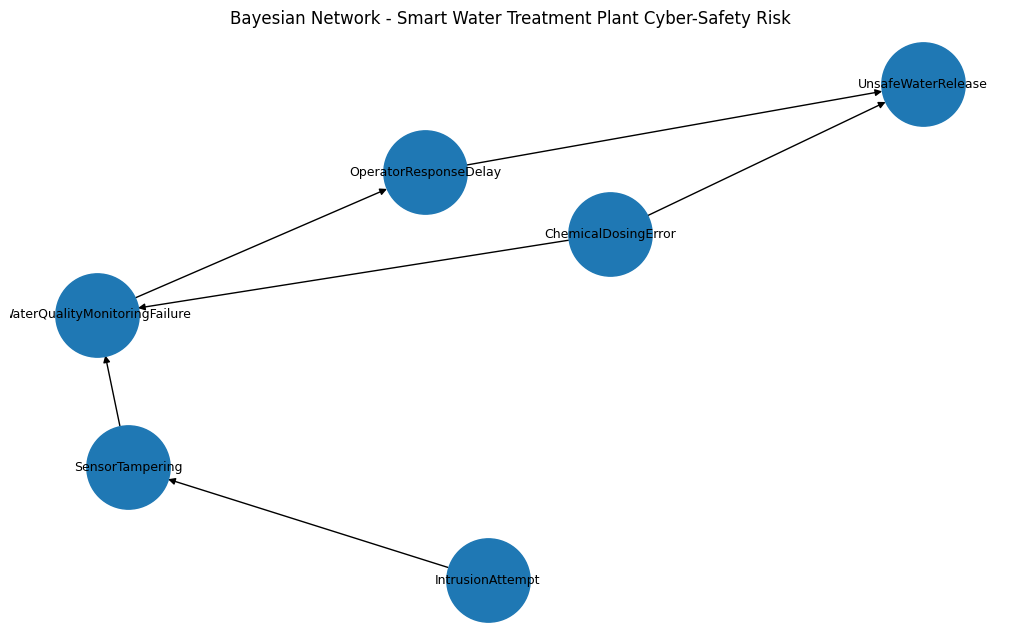

In [5]:
# Create directed graph
graph = nx.DiGraph()

# Add model edges
graph.add_edges_from(model.edges())

# Create figure
plt.figure(figsize=(10, 6))

# Generate node positions
pos = nx.spring_layout(graph, seed=42)

# Draw Bayesian Network
nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=3600,
    font_size=9,
    arrows=True
)

# Add title
plt.title("Bayesian Network - Smart Water Treatment Plant Cyber-Safety Risk")

# Display graph
plt.show()